#Sales Analysis using DS Techniques


In [3]:
#Import the Librarys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported the Module")


Imported the Module


In [4]:
#Load the Sales Data

dataset_path=r"datasets\AusApparalSales4thQrt2020.csv"

df_SalesData=pd.read_csv(dataset_path)

df_SalesData.head() #7560 Rows

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


1.	Data wrangling
a.	Ensure that the data is clean and free from any missing or incorrect entries.
○	Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().
b.	Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).
c.	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)
d.	Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.



Task 1-a
1.	Ensure that the data is clean and free from any missing or incorrect entries.
2	Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().

In [5]:
#Data Wrangling

#Validate the Sales Data Data Types

df_SalesData.dtypes

#a.Ensure that the data is clean and free from any missing or incorrect entries.

#Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().

print(f"Missing Values in each column:\n{df_SalesData.isna().sum()}") #no missing values in all the 6 columns

print(f"Non-Missing Values in each column:\n{df_SalesData.notna().sum()}") #7560 non-missing values in all the 6 columns

#Since there is no missing values and all the columns have values, the sales data is clean and proceed to next steps

 




Missing Values in each column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64
Non-Missing Values in each column:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


Task 1-b
b.	Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).

In [6]:
#Task 1-B,

df_SalesData.dropna(how="all", inplace=True) #drop the rows with all missing values, but there are no missing values in the dataset, so it will not drop any rows
df_SalesData.info() #No rows with all missing values, so the dataset remains unchanged with 7560 rows and 6 columns.


df_SalesData.fillna(df_SalesData["Sales"].mean(), inplace=True) #fill the missing values in the "Sales" column with the mean of the "Sales" column, but there are no missing values in the "Sales" column, so it will not fill any values
df_SalesData.info() #No missing values in the "Sales" column, so the dataset remains unchanged with 7560 rows and 6 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


#Task 1-c
c.	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)

In [7]:
#Task 1-c, Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)

#scale the range, Normalization is required when the numeric values are too far hence we need to scale the range of the numeric values to a standard range, such as 0 to 1, to ensure that all features contribute equally to the analysis and prevent any single feature from dominating the results.

#pip install scikit-learn

#from sklearn.preprocessing import MinMaxScaler
 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
print("Working fine!")
 
scaler=MinMaxScaler() #Create an instance of the MinMaxScaler class, which will be used to perform normalization on the data.

#From Data from take sale and unit column to scale up.

df_SalesData[["Sales","Unit"]]=scaler.fit_transform(df_SalesData[["Sales","Unit"]]) #Apply the fit_transform method of the scaler object to the "Sales" and "Units" columns of the df_SalesData DataFrame. This will normalize the values in these columns to a range between 0 and 1.
df_SalesData[["Sales","Unit"]]

Working fine!


,Sales,Unit
0,0.095238,0.095238
1,0.095238,0.095238
2,0.031746,0.031746
3,0.206349,0.206349
4,0.015873,0.015873
...,...,...
7555,0.190476,0.190476
7556,0.206349,0.206349
7557,0.206349,0.206349
7558,0.142857,0.142857


Task 1-D : d.	Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.

In [13]:
#Task 1-d

state_sales=df_SalesData.groupby("State")["Sales"].sum().reset_index() #Group the df_SalesData DataFrame by the "State" column and calculate the sum of the "Sales" column for each state. The result is stored in a new DataFrame called state_sales, which contains two columns: "State" and "Sales".
state_sales.head(4) #Display the first 4 rows of the state_sales DataFrame to verify the results of the grouping and summation operation.

print("State-wise total sales:")
print(state_sales) #list the total sales for each state,.

#Sort the values by state to know the state with the highest sales.
state_sales_sorted=state_sales.sort_values(by="Sales", ascending=False) #Sort the state_sales DataFrame by the "Sales" column in descending order, so that the states with the highest sales appear at the top of the DataFrame. The sorted DataFrame is stored in a new variable called state_sales_sorted.
(state_sales_sorted) #Display the rows of the state_sales_sorted

State-wise total sales:
  State       Sales
0   NSW  441.714286
1    NT  109.079365
2   QLD  177.888889
3    SA  339.412698
4   TAS  110.222222
5   VIC  635.968254
6    WA  106.365079


,State,Sales
5,VIC,635.968254
0,NSW,441.714286
3,SA,339.412698
2,QLD,177.888889
4,TAS,110.222222
1,NT,109.079365
6,WA,106.365079


2.	Data analysis
 

Task 2-a
a.	Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.

In [19]:
#a.	Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.

print(df_SalesData[["Sales","Unit"]].describe()) #Calculate and display descriptive statistics for the "Sales" and "Unit" columns of the df_SalesData DataFrame, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values.

#describe() is not having Mode function, so we will calculate mode separately.
from scipy import stats
mode_sales=stats.mode(df_SalesData[["Sales","Unit"]]) #Calculate the mode of the "Sales" & Unit column in the df_SalesData DataFrame using the mode function from the scipy.stats module. The result is stored in a variable called mode_sales.

mode_sales

             Sales         Unit
count  7560.000000  7560.000000
mean      0.254054     0.254054
std       0.204784     0.204784
min       0.000000     0.000000
25%       0.095238     0.095238
50%       0.190476     0.190476
75%       0.380952     0.380952
max       1.000000     1.000000


ModeResult(mode=array([0.11111111, 0.11111111]), count=array([406, 406]))

2-b
b.	Identify the group with the highest sales and the group with the lowest sales based on the data provided.

In [ ]:
#2-b & 2-C: b.	Identify the group with the highest sales and the group with the lowest sales based on the data provided.
top_sales_group=df_SalesData.groupby("Group")["Sales"].sum().idxmax() #Group the df DataFrame by the "Group" column, calculate the sum of the "Sales" column for each group, and then identify the index of the group with the highest total sales using the idxmax() function. The result is stored in a variable called top_sales_group.
bottom_sales_group=df_SalesData.groupby("Group")["Sales"].sum().idxmin() #Group the df DataFrame by the "Group" column, calculate the sum of the "Sales" column for each group, and then identify the index of the group with the lowest total sales using the idxmin() function. The result is stored in a variable called bottom_sales_group.   

print("The group with highest sales is:", top_sales_group)
print("The group with lowest sales is:", bottom_sales_group)

The group with highest sales is:  Men
The group with lowest sales is:  Seniors


#Skipping Task 2-C since it is same as Task 2-B

#2-D d.	Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.

In [25]:
#Task 2-D #d.	Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.

#Convert the Date Column to Datetime format since it is show as object data type.
df_SalesData["Date"]=pd.to_datetime(df_SalesData["Date"]) #Convert the "Date" column using the pd.to_datetime() function.
df_SalesData.info() #After converting the "Date" column to datetime format. validate it and it shows as DateTime

#Create Week column

df_SalesData["Week"]=df_SalesData["Date"].dt.isocalendar().week  

#Create Month column
df_SalesData["Month"]=df_SalesData["Date"].dt.month

#Create Quarter column
df_SalesData["Quarter"]=df_SalesData["Date"].dt.quarter


df_SalesData


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     7560 non-null   datetime64[ns]
 1   Time     7560 non-null   object        
 2   State    7560 non-null   object        
 3   Group    7560 non-null   object        
 4   Unit     7560 non-null   float64       
 5   Sales    7560 non-null   float64       
 6   Week     7560 non-null   UInt32        
 7   Month    7560 non-null   int32         
 8   Quarter  7560 non-null   int32         
dtypes: UInt32(1), datetime64[ns](1), float64(2), int32(2), object(3)
memory usage: 450.5+ KB


,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter
0,2020-10-01,Morning,WA,Kids,0.095238,0.095238,40,10,4
1,2020-10-01,Morning,WA,Men,0.095238,0.095238,40,10,4
2,2020-10-01,Morning,WA,Women,0.031746,0.031746,40,10,4
3,2020-10-01,Morning,WA,Seniors,0.206349,0.206349,40,10,4
4,2020-10-01,Afternoon,WA,Kids,0.015873,0.015873,40,10,4
...,...,...,...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TAS,Seniors,0.190476,0.190476,53,12,4
7556,2020-12-30,Evening,TAS,Kids,0.206349,0.206349,53,12,4
7557,2020-12-30,Evening,TAS,Men,0.206349,0.206349,53,12,4
7558,2020-12-30,Evening,TAS,Women,0.142857,0.142857,53,12,4


In [27]:
#Weekly Sales

weekly_sales=df_SalesData.groupby("Week")["Sales"].sum().reset_index() #Group the sales by week.

print("Weekly Sales:")
print(weekly_sales) #Display the weekly sales report, which shows the total sales for each week.  

#monthly Sales
monthly_sales=df_SalesData.groupby("Month")["Sales"].sum().reset_index() #Group the sales by month.
print("Monthly Sales:")
print(monthly_sales) #Display the monthly sales report, which shows the total sales for each month. 


#Quarterly Sales
quarterly_sales=df_SalesData.groupby("Quarter")["Sales"].sum().reset_index() #Group the sales by quarter.
print("Quarterly Sales:")
print(quarterly_sales) #Display the quarterly sales report, which shows the total sales for each quarter.

Weekly Sales:
    Week       Sales
0     40   84.857143
1     41  152.777778
2     42  150.476190
3     43  151.587302
4     44  122.460317
5     45  113.809524
6     46  115.761905
7     47  115.380952
8     48  117.698413
9     49  169.412698
10    50  181.492063
11    51  182.317460
12    52  183.047619
13    53   79.571429
Monthly Sales:
   Month       Sales
0     10  645.650794
1     11  495.761905
2     12  779.238095
Quarterly Sales:
   Quarter        Sales
0        4  1920.650794


3.	Data visualization
 

#Task 3-a

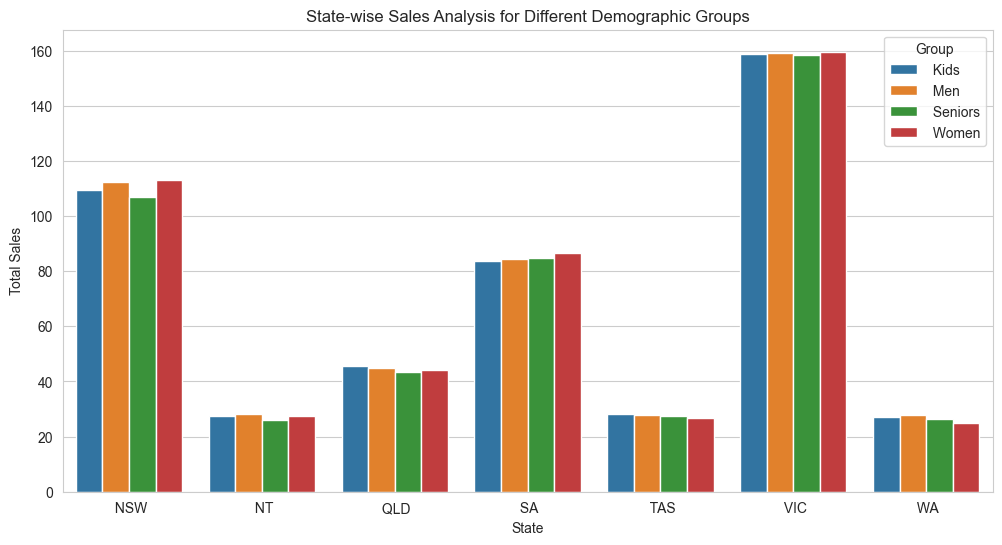

In [30]:
#a.	Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:
#State-wise sales analysis for different demographic groups (kids, women, men, and seniors).
#Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.
#Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales.

sns.set_style("whitegrid") #Set the style of the seaborn plots to "whitegrid"
%matplotlib inline

#State wise sales analysis for different demographic groups (kids, women, men, and seniors).

state_group_sales=df_SalesData.groupby(["State","Group"])["Sales"].sum().reset_index() #Group the sales data by both "State" and "Group" columns

plt.figure(figsize=(12,6)) #Set the figure size for the plot to 12 inches in width and 6 inches in height.
sns.barplot(data=state_group_sales, x="State", y="Sales", hue="Group") #Create a bar plot using seaborn's barplot function, where the x-axis represents the "State", the y-axis represents the total "Sales", and the bars are colored based on the "Group" (demographic

plt.title("State-wise Sales Analysis for Different Demographic Groups") #Set the title of the plot to "State-wise Sales Analysis for Different Demographic Groups"
plt.xlabel("State") #Set the label for the x-axis to "State"
plt.ylabel("Total Sales") #Set the label for the y-axis to "Total Sales"
plt.legend(title="Group") #Add a legend to the plot with the title "Group" to differentiate between the different demographic groups.
plt.show() #Display the plot on the screen.





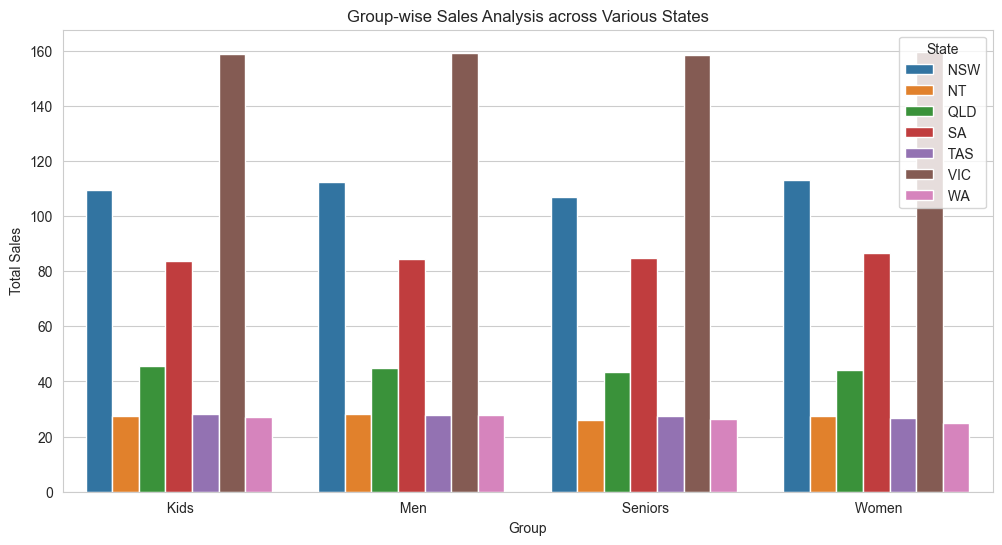

In [31]:
#3 a 2 Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.
group_state_sales=df_SalesData.groupby(["Group","State"])["Sales"].sum().reset_index() #Group the sales data by both "Group" and "State" columns
plt.figure(figsize=(12,6)) #Set the figure size for the plot to 12 inches in width and 6 inches in height.
sns.barplot(data=group_state_sales, x="Group", y="Sales", hue="State") #Create a bar plot using seaborn's barplot function, where the x-axis represents the "Group" 
plt.title("Group-wise Sales Analysis across Various States") #Set the title of the plot to "Group-wise Sales Analysis across Various States"
plt.xlabel("Group") #Set the label for the x-axis to "Group"
plt.ylabel("Total Sales") #Set the label for the y-axis to "Total Sales"
plt.legend(title="State") #Add a legend to the plot with the title "State" to differentiate between the various states.
plt.show() #Display the plot on the screen.


4.	Report generation